# Prague Air Quality Hub
## Project Deliverable Pipeline & Exploratory Data Analysis (EDA)

This document serves as the data architecture record and exploratory core accompanying the interactive air quality dashboard. The objective of this analysis is to parse, visualize, and explore the underlying temporal and spatial relationships between urban atmospheric pollutants and microclimate meteorological conditions.

### Contents:
1. **Data Architecture Overview:** Quantify structural dimensions, evaluate dataset completeness, and isolate missing data flags.
2. **Frequency Spectrum Analysis:** Map structural distribution density variations across target pollutants ($PM_{10}$, $NO_2$, $NO_x$) and primary weather indicators.
3. **Anthropogenic Chrono-Analysis:** Uncover weekly human behavioral cycles by plotting hourly concentration patterns across the tracking time horizon.
4. **Geographic Sensor Network Alignment:** Evaluate the spatial proximity matrix mapping air quality observation centers to their nearest co-located weather station grids.

---

In [1]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx

# set plotting style 
plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_context("notebook", font_scale=1.1)

# load data
df = pd.read_csv("../data/processed/processed_data.csv")
df['startTime'] = pd.to_datetime(df['startTime'])

# preprocess time components
df = pd.read_csv("../data/processed/processed_data.csv")
df['startTime'] = pd.to_datetime(df['startTime'])
df['hour'] = df['startTime'].dt.hour
df['dayofweek'] = df['startTime'].dt.dayofweek

In [2]:
# dictionary mapping core parameters 
VARIABLE_MAP = {
    "air_PM10":  {"name": r"PM10", "unit": "µg/m³", "color": "#1E88E5", "limit": 50.0},
    "air_NO2":   {"name": r"NO2",  "unit": "µg/m³", "color": "#D81B60", "limit": 200.0},
    "air_NOx":   {"name": r"NOₓ",  "unit": "µg/m³", "color": "#8E24AA", "limit": 200.0},
    "weather_T": {"name": "Air Temperature", "unit": "°C", "color": "#FF8F00"},
    "weather_TMA": {"name": "Max Air Temperature", "unit": "°C", "color": "#E65100"},
    "weather_TMI": {"name": "Min Air Temperature", "unit": "°C", "color": "#F57C00"},
    "weather_F": {"name": "Wind Speed", "unit": "m/s", "color": "#4CAF50"},
    "weather_H": {"name": "Relative Humidity", "unit": "%", "color": "#00BCD4"},
    "weather_P": {"name": "Atmospheric Pressure", "unit": "hPa", "color": "#9C27B0"},
    "weather_SRA10M": {"name": "Precipitation", "unit": "mm", "color": "#3F51B5"}
}

# explicit grouping of variables
target_cols = ["air_PM10", "air_NO2", "air_NOx"]
weather_cols = ["weather_T", "weather_TMA", "weather_TMI", "weather_F", "weather_H", "weather_P", "weather_SRA10M"]
analysis_cols = target_cols + ["weather_T", "weather_F", "weather_H", "weather_P", "weather_SRA10M"]

# synchronize seaborn plotting theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "grid.color": "#EAEAEA"
})

In [3]:
# OUTPUT 1: DATA STRUCTURE SUMMARY ----

num_rows, num_cols = df.shape
min_date = df['startTime'].min()
max_date = df['startTime'].max()
time_span = max_date - min_date
unique_stations = df['air_station_name'].unique()

print(f"--------------------------------------------------")
print(f"          DATA ARCHITECTURE SUMMARY               ")
print(f"--------------------------------------------------")
print(f"• Total Observations (Rows):{num_rows:,}")
print(f"• Feature & Attribute Schema Space:{num_cols}")
print(f"• Baseline Temporal Window Boundary:{min_date.date()} to {max_date.date()}")
print(f"• Complete Tracking Horizon Depth:{time_span.days} days")
print(f"• Active Air Stations Quantified:{len(unique_stations)}")
for s in unique_stations:
    print(f"   --> {s}")
print(f"--------------------------------------------------")
print("\nMissing Values:")
missing_summary = df[analysis_cols].isnull().sum()
print(missing_summary)

--------------------------------------------------
          DATA ARCHITECTURE SUMMARY               
--------------------------------------------------
• Total Observations (Rows):69,840
• Feature & Attribute Schema Space:56
• Baseline Temporal Window Boundary:2025-01-01 to 2025-12-31
• Complete Tracking Horizon Depth:364 days
• Active Air Stations Quantified:8
   --> Praha 1-n. Republiky
   --> Praha 10-Vršovice
   --> Praha 2-Legerova (hot spot)
   --> Praha 2-Riegrovy sady
   --> Praha 4-Libuš
   --> Praha 7-Holešovice
   --> Praha 8-Karlín
   --> Praha 9-Vysočany
--------------------------------------------------

Missing Values:
air_PM10          1096
air_NO2           4069
air_NOx           4162
weather_T            0
weather_F            0
weather_H            0
weather_P            0
weather_SRA10M       0
dtype: int64


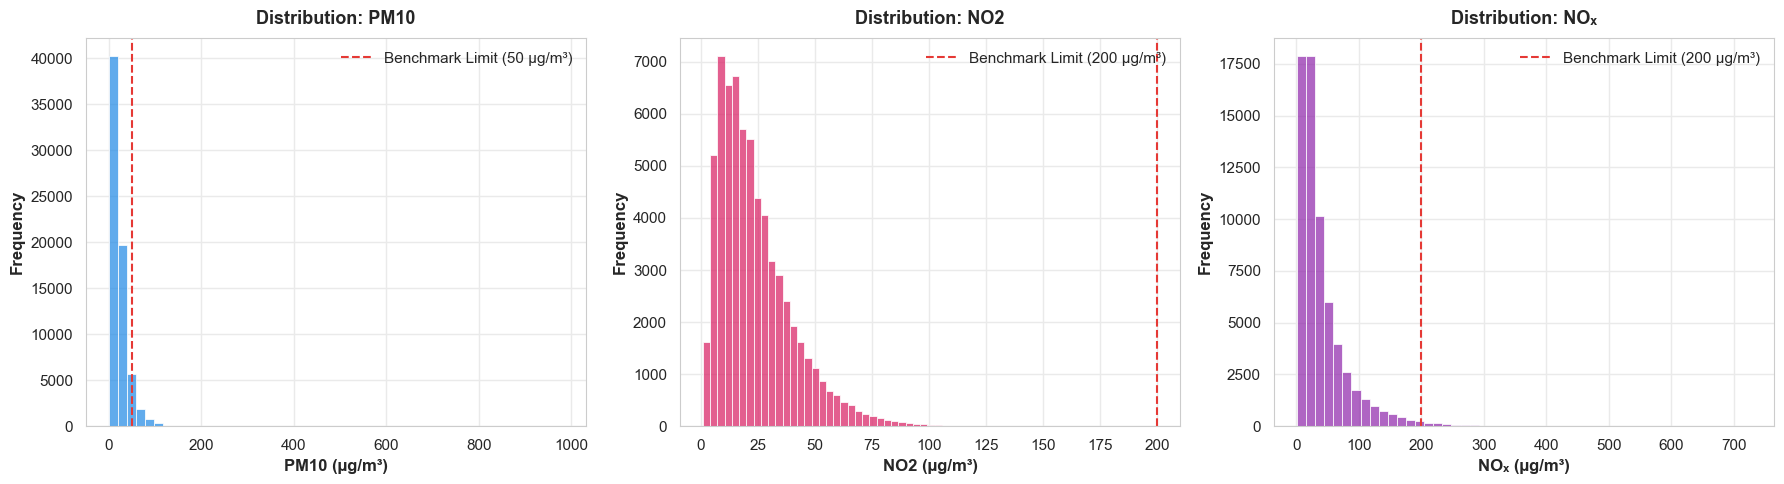

In [4]:
# OUTPUT 2: AIR POLLUTANT DISTRIBUTIONS ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(target_cols):
    meta = VARIABLE_MAP[col]
    sns.histplot(df[col].dropna(), bins=50, ax=axes[idx], color=meta["color"], alpha=0.7)
    axes[idx].axvline(meta["limit"], color='#E53935', linestyle='--', linewidth=1.5, 
                      label=f"Benchmark Limit ({int(meta['limit'])} {meta['unit'].replace('$', '')})")
    axes[idx].set_title(f"Distribution: {meta['name']}", fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel(f"{meta['name']} ({meta['unit']})", fontweight='semibold')
    axes[idx].set_ylabel("Frequency", fontweight='semibold')
    axes[idx].legend(loc="upper right")

plt.tight_layout()
plt.show()

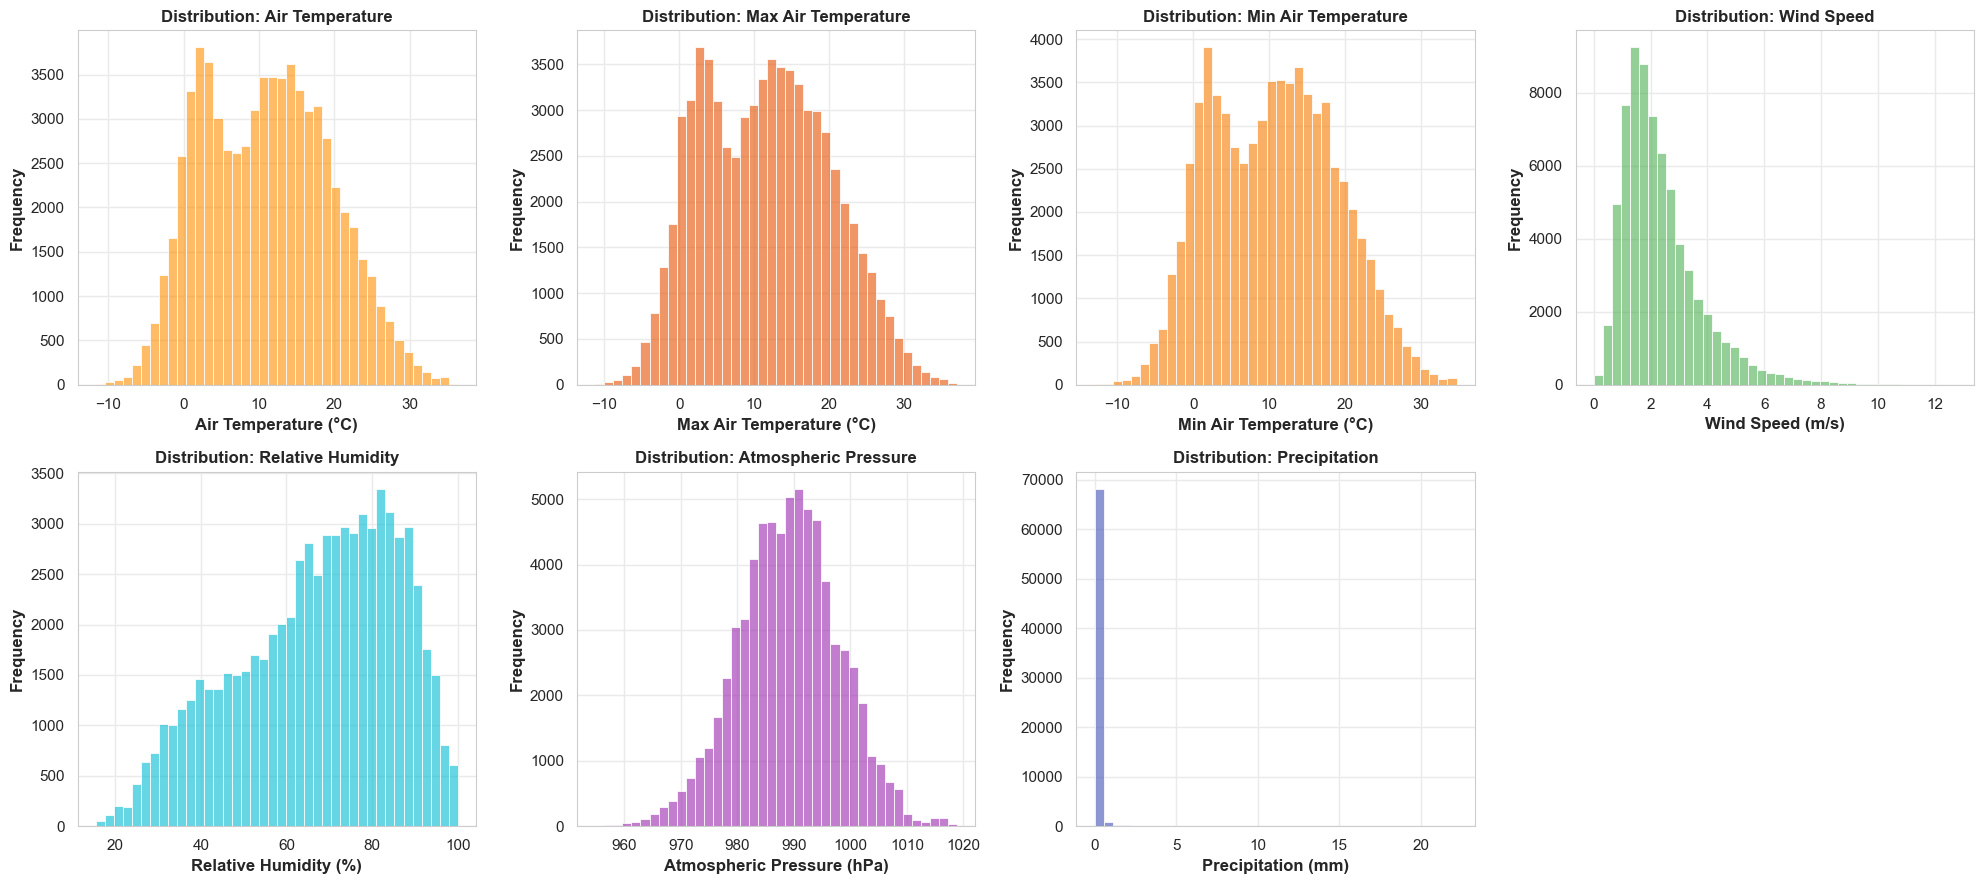

In [5]:
# OUTPUT 3: DISTRIBUTION OF THE WEATHER VARIABLES ----

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, col in enumerate(weather_cols):
    meta = VARIABLE_MAP[col]
    if col in df.columns:
        sns.histplot(df[col].dropna(), bins=40, ax=axes[idx], color=meta["color"], alpha=0.6)
        axes[idx].set_title(f"Distribution: {meta['name']}", fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(f"{meta['name']} ({meta['unit']})", fontweight='semibold')
        axes[idx].set_ylabel("Frequency", fontweight='semibold')
    else:
        axes[idx].axis('off')

# hide the final leftover axis title
if len(weather_cols) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

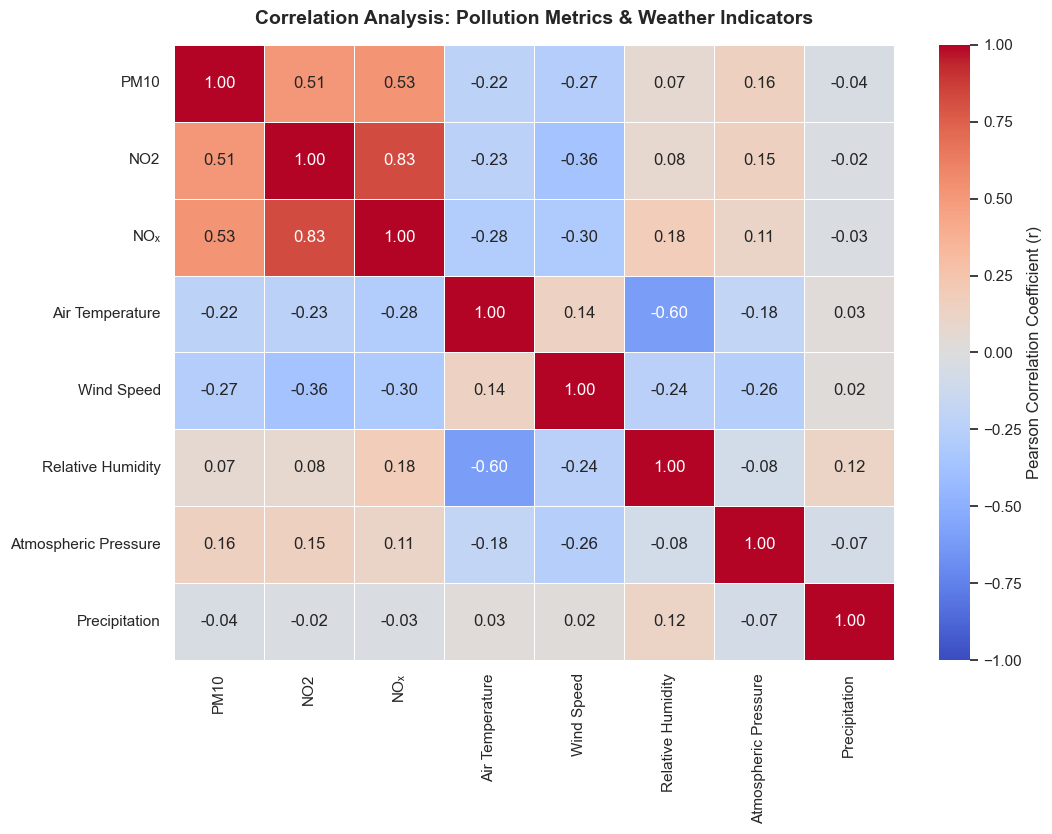

In [6]:
# OUTPUT 4: CORRELATION MATRIX ----

plt.figure(figsize=(11, 8.5))

corr_matrix = df[analysis_cols].corr()
display_labels = [VARIABLE_MAP[col]["name"].replace("$", "") for col in analysis_cols]
corr_matrix.columns = display_labels
corr_matrix.index = display_labels

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson Correlation Coefficient (r)"})
plt.title('Correlation Analysis: Pollution Metrics & Weather Indicators', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

C:\Users\jachy\AppData\Local\Temp\ipykernel_20680\1842153353.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


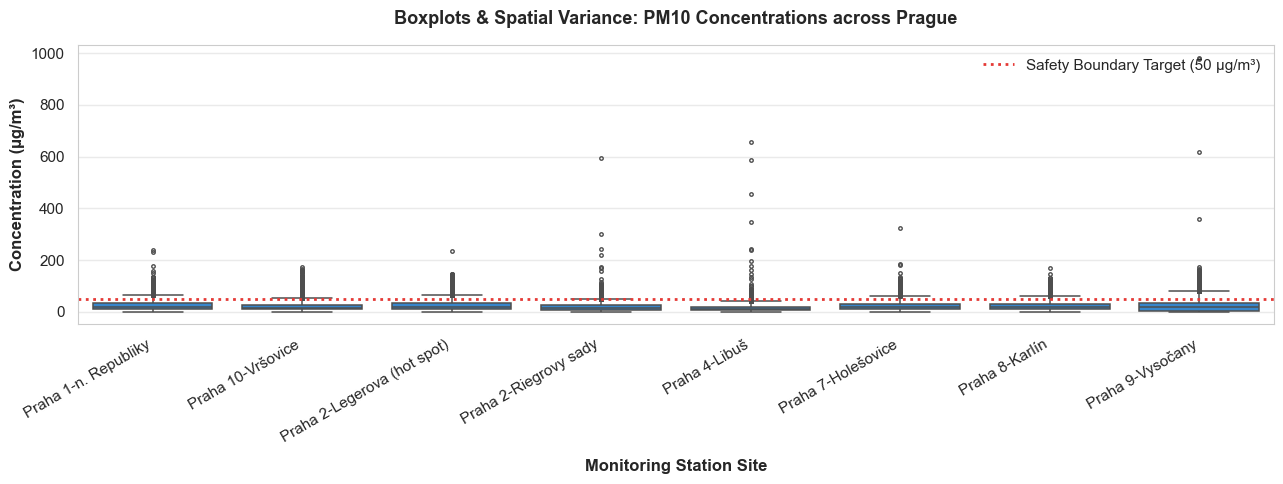

C:\Users\jachy\AppData\Local\Temp\ipykernel_20680\1842153353.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


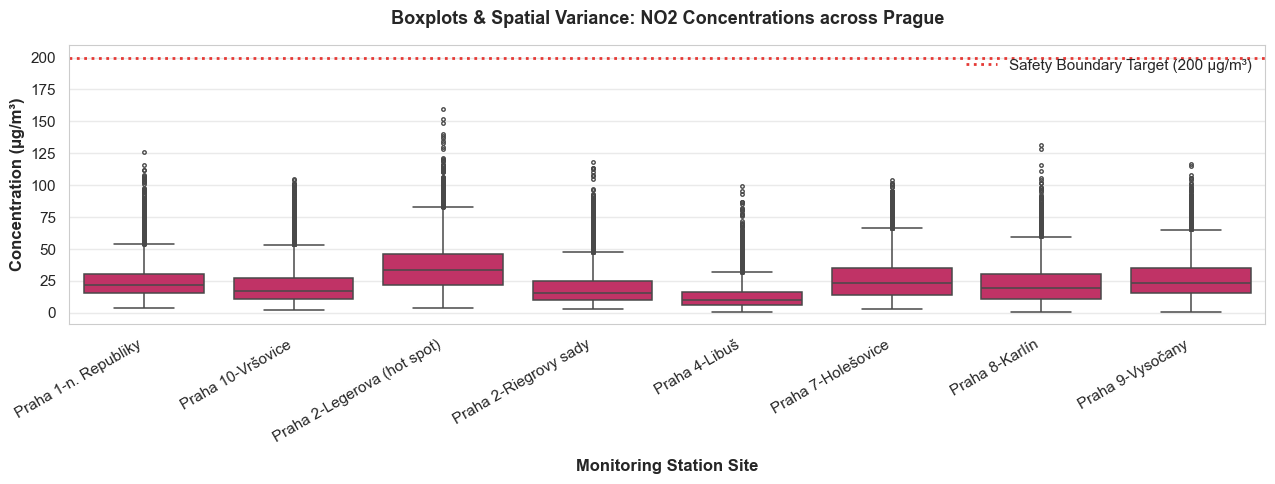

C:\Users\jachy\AppData\Local\Temp\ipykernel_20680\1842153353.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


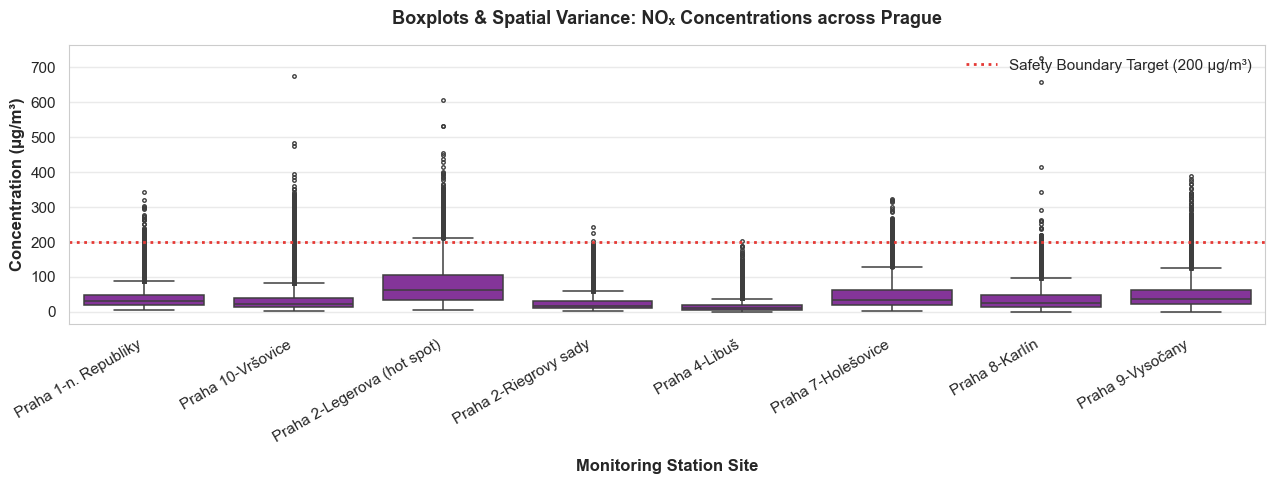

In [7]:
# OUTPUT 5: BOXPLOTS PER AIR QUALITY STATION ----

for col in target_cols:
    meta = VARIABLE_MAP[col]
    fig, ax = plt.subplots(figsize=(13, 5))
    
    sns.boxplot(
        data=df, 
        x="air_station_name", 
        y=col, 
        ax=ax, 
        color=meta["color"],
        fliersize=2.5,
        linewidth=1.1
    )
    # add safety benchmarks
    ax.axhline(y=meta["limit"], color='#E53935', linestyle=':', linewidth=2, 
               label=f"Safety Boundary Target ({int(meta['limit'])} {meta['unit'].replace('$', '')})")
    
    ax.set_title(f"Boxplots & Spatial Variance: {meta['name']} Concentrations across Prague", fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("Monitoring Station Site", fontweight='bold', labelpad=10)
    ax.set_ylabel(f"Concentration ({meta['unit']})", fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

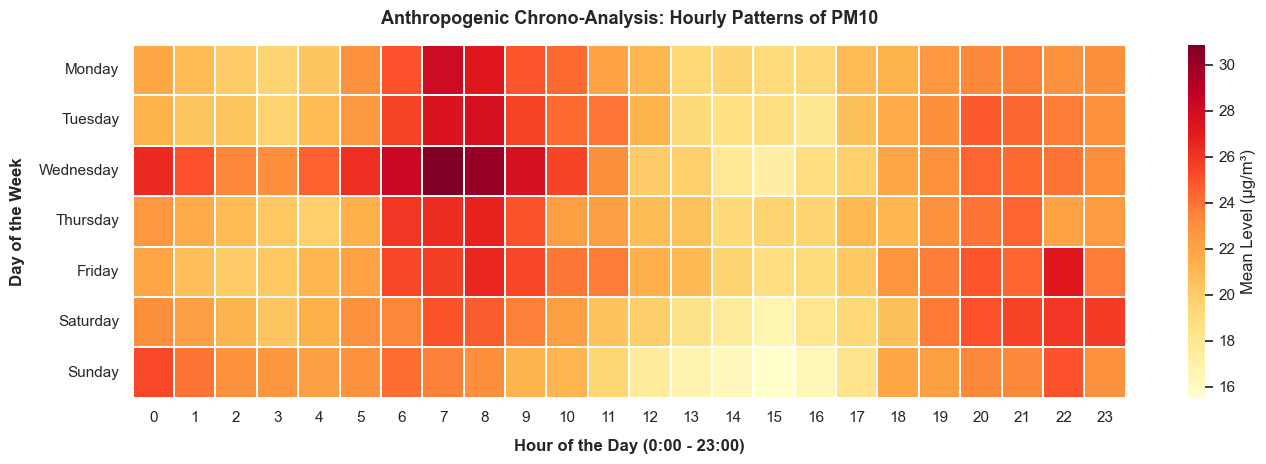

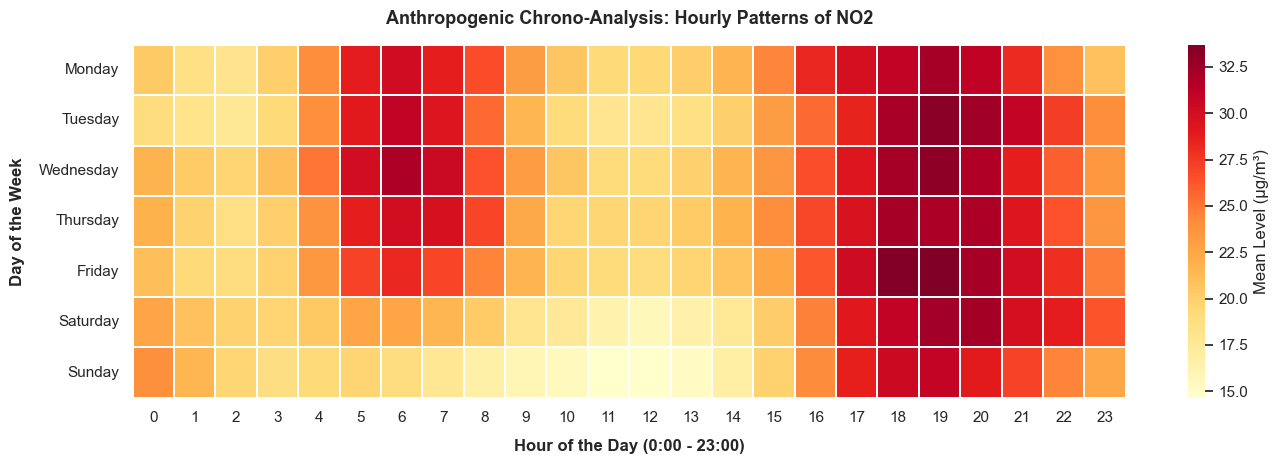

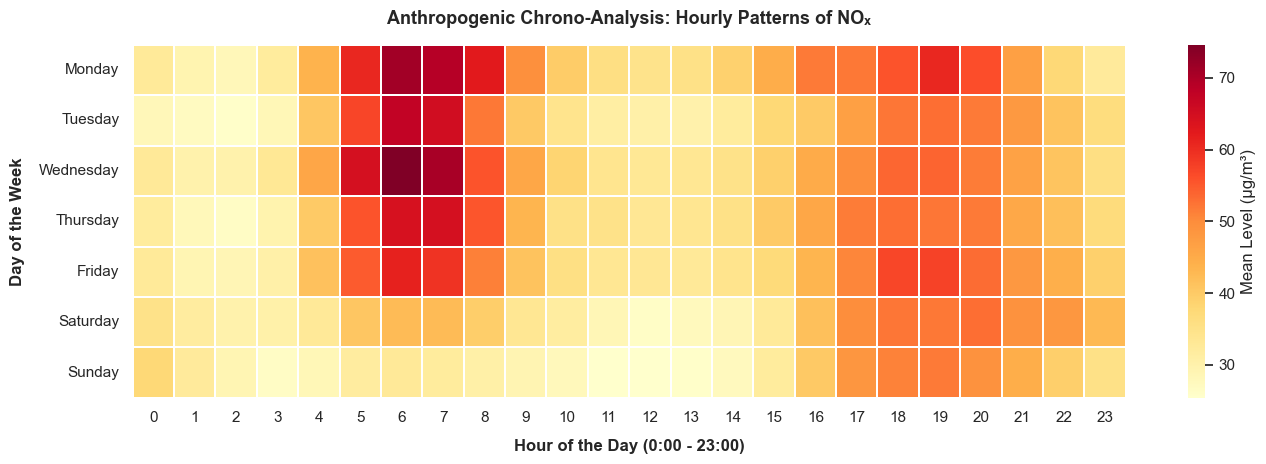

In [8]:
# OUTPUT 6: DAILY AND HOURLY PATTERNS ----

# get names of the days of the week
day_labels = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

for col in target_cols:
    meta = VARIABLE_MAP[col]
    
    # calculate means grouped dynamically by hour and weekday profile mappings
    temporal_agg = df.groupby(['dayofweek', 'hour'])[col].mean().reset_index()
    pivot_table = temporal_agg.pivot(index="dayofweek", columns="hour", values=col)
    pivot_table.index = pivot_table.index.map(day_labels)
    
    plt.figure(figsize=(14, 4.8))
    sns.heatmap(
        pivot_table,
        cmap="YlOrRd",
        cbar_kws={"label": f"Mean Level ({meta['unit']})"},
        linewidths=0.2
    )
    
    plt.title(f"Anthropogenic Chrono-Analysis: Hourly Patterns of {meta['name']}", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Hour of the Day (0:00 - 23:00)", fontweight='bold', labelpad=10)
    plt.ylabel("Day of the Week", fontweight='bold', labelpad=10)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

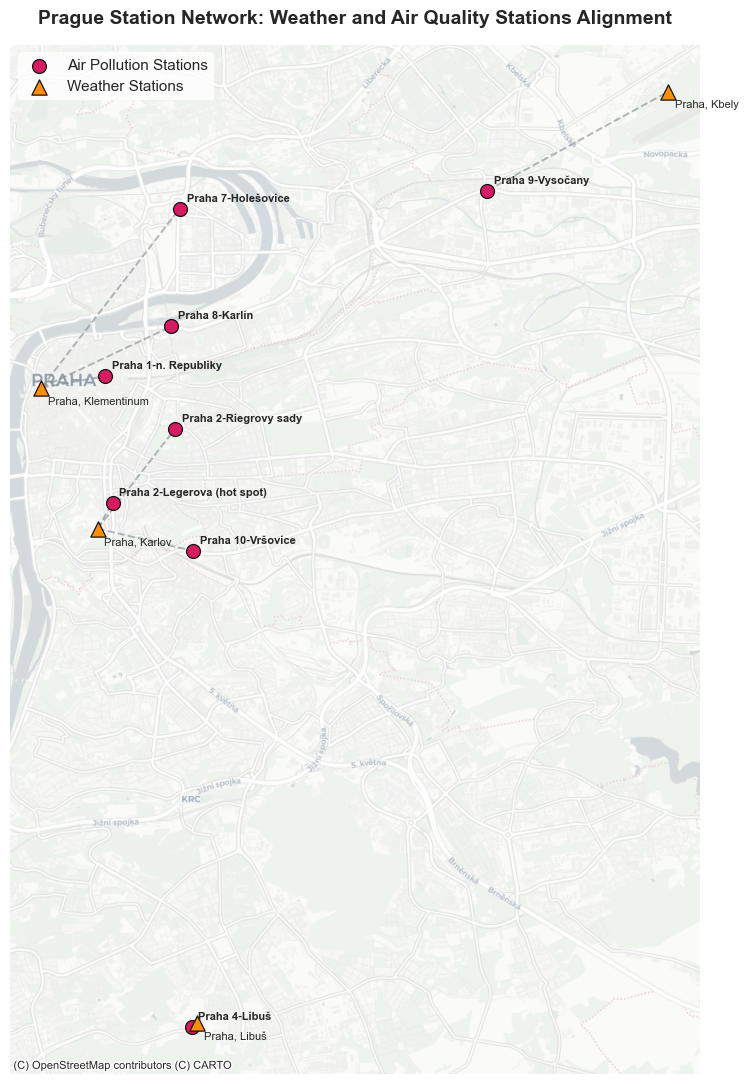

In [9]:
# OUTPUT 7: MAP OF THE STATIONS ---

# get the coordinates
coord_cols = ["weather_lat", "weather_lon", "air_lat", "air_lon"]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors="coerce")

# get unique matchings of weather and air quality stations from the already-matched pairs in the dataset
weather_stations = df[["weather_station_name", "weather_lat", "weather_lon"]].dropna().drop_duplicates().copy()
air_stations = df[["air_station_name", "air_lat", "air_lon"]].dropna().drop_duplicates().copy()
station_pairs = df[["air_station_name", "air_lat", "air_lon", "weather_station_name", "weather_lat", "weather_lon"]].dropna().drop_duplicates().copy()

# initialize geographic structures from geopandas
gdf_weather = gpd.GeoDataFrame(weather_stations, geometry=gpd.points_from_xy(weather_stations["weather_lon"], weather_stations["weather_lat"]), crs="EPSG:4326")
gdf_air = gpd.GeoDataFrame(air_stations, geometry=gpd.points_from_xy(air_stations["air_lon"], air_stations["air_lat"]), crs="EPSG:4326")

pair_lines = [
    {
        "air_station": r["air_station_name"],
        "weather_station": r["weather_station_name"],
        "geometry": LineString([(r["air_lon"], r["air_lat"]), (r["weather_lon"], r["weather_lat"])])
    } for _, r in station_pairs.iterrows()
]
gdf_pairs = gpd.GeoDataFrame(pair_lines, crs="EPSG:4326")

# Reproject spatial systems into Web Mercator metric projection for standard basemaps
gdf_weather = gdf_weather.to_crs(epsg=3857)
gdf_air = gdf_air.to_crs(epsg=3857)
gdf_pairs = gdf_pairs.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

# connect with line
gdf_pairs.plot(ax=ax, linewidth=1.4, alpha=0.6, color="#7F8C8D", linestyle="--", zorder=1)
# map air stations
gdf_air.plot(ax=ax, markersize=100, marker="o", label="Air Pollution Stations", color="#D81B60", alpha=1.0, edgecolor="#111111", linewidth=0.9, zorder=3)
# map weather stations
gdf_weather.plot(ax=ax, markersize=120, marker="^", label="Weather Stations", color="#FF8F00", alpha=1.0, edgecolor="#111111", linewidth=0.9, zorder=4)

# display names and offset them
for _, row in gdf_air.iterrows():
    ax.annotate(row["air_station_name"], xy=(row.geometry.x, row.geometry.y), xytext=(5, 5), textcoords="offset points", fontsize=8, fontweight="bold", zorder=5)
for _, row in gdf_weather.iterrows():
    ax.annotate(row["weather_station_name"], xy=(row.geometry.x, row.geometry.y), xytext=(5, -12), textcoords="offset points", fontsize=8, zorder=5)

# append background map canvas layers
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Prague Station Network: Weather and Air Quality Stations Alignment", fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()